# AromaticFlowersBD: Deep Learning Pipeline — **WITHOUT CLAHE**
## Multi-Model CNN with Scheduler Comparison, Weighted Ensemble & Grad-CAM

**Dataset:** AromaticFlowersBD (Mendeley Data, DOI: 10.17632/327kkgxzdn.1)
**Classes:** 12 Aromatic Flower Species
**Preprocessing mode of this notebook:** `USE_CLAHE = False`

This notebook is one of **two self-contained, independently-executable companion
notebooks**:

| Notebook | Preprocessing |
|---|---|
| `aromaticflowersbd_with_clahe.ipynb` | CLAHE applied to **train, validation, and test** sets |
| `aromaticflowersbd_without_clahe.ipynb` | CLAHE **never** applied to any split |

Only one preprocessing condition is used throughout this notebook — every
dataset split (train / validation / test) and every experiment (scheduler
comparison, main training, augmentation ablation, ensemble, Grad-CAM) shares the
exact same `no-CLAHE` transform pipeline. There is
no mixing of preprocessing between splits or between experiments.

### Pipeline contents
| # | Section | Details |
|---|---------|---------|
| 1 | Data analysis & cleaning | Corrupted/duplicate removal, class distribution, resolution stats |
| 2 | Stratified 60/20/20 split | Train / Validation / Test, fixed seed |
| 3 | Preprocessing | No CLAHE — plain resize + normalize for all splits |
| 4 | Augmentation (8 techniques) | H-Flip, V-Flip, Rotate ±90°, Brightness ±30%, 3px Blur, 2.5% Pixel Noise — applied only to the training split |
| 5 | LR Scheduler experiment | **EfficientNetB0** trained with 4 schedulers (CosineAnnealingLR, StepLR, ReduceLROnPlateau, OneCycleLR) |
| 6 | Main training | 4 backbones (ResNet50, DenseNet121, EfficientNetB0, ConvNeXt-Tiny) with the best scheduler |
| 7 | Evaluation | Metrics, confusion matrices, ROC curves |
| 8 | Grad-CAM | Individual models **and** the Weighted Ensemble, same format |

Reproducibility: a fixed random seed (`SEED = 42`) is used everywhere — data
split, augmentation sampling, model init, and training.


## Phase 0: Environment Setup & Library Installation

In [ ]:
# Install required libraries
!pip install -q timm imagehash scikit-learn seaborn matplotlib opencv-python-headless grad-cam torchmetrics statsmodels

import os
import sys
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
import imagehash
import cv2
import copy
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize
from scipy.stats import wilcoxon
from scipy import stats

warnings.filterwarnings('ignore')

# ============================================================
# THE single switch that decides this notebook's preprocessing.
# ============================================================
USE_CLAHE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'USE_CLAHE = {USE_CLAHE}  (WITH CLAHE)')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.0 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4
VRAM: 15.64 GB
USE_CLAHE = False  (WITH CLAHE)


## Phase 1: Configuration & Dataset Path Setup

In [ ]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# ============================================================
# CONFIGURATION — Set path to your dataset in Google Drive
# ============================================================

# 👈 CHANGE THIS to match the exact path in your Google Drive
DRIVE_DATASET_PATH = Path('/content/drive/MyDrive/aromaticflowersbd')

if DRIVE_DATASET_PATH.exists():
    DATA_ROOT = DRIVE_DATASET_PATH
    print(f'✓ Found dataset at Google Drive path: {DATA_ROOT}')
else:
    # Fallback search inside Google Drive if exact path is not found directly
    drive_search = list(Path('/content/drive/MyDrive').rglob('aromaticflowersbd'))
    if drive_search:
        DATA_ROOT = drive_search[0]
        print(f'✓ Located dataset in Google Drive: {DATA_ROOT}')
    else:
        raise FileNotFoundError(
            f"Could not find dataset at {DRIVE_DATASET_PATH}. "
            "Please update DRIVE_DATASET_PATH to your exact Google Drive folder."
        )

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 10
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2  # Set to 2 for Colab CPU limits to prevent DataLoader crashes
PATIENCE     = 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Output directory stored locally on fast Colab SSD
_BASE_OUT = Path('/content/outputs')
OUT_DIR = _BASE_OUT / 'with_clahe'
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'models').mkdir(exist_ok=True)
(OUT_DIR / 'figures').mkdir(exist_ok=True)
(OUT_DIR / 'gradcam').mkdir(exist_ok=True)
print('Local Output Directory:', OUT_DIR)

CLASS_NAMES = [
    'Bakul', 'Beli', 'Champa', 'Golap', 'Hasna Hena',
    'Jui', 'Kath Golap', 'Madhobi Lata', 'Rajani Gandha',
    'Sheuli', 'Sondha Maloti', 'Tagar'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Mounted at /content/drive
✓ Found dataset at Google Drive path: /content/drive/MyDrive/aromaticflowersbd
Local Output Directory: /content/outputs/with_clahe
Classes (12): ['Bakul', 'Beli', 'Champa', 'Golap', 'Hasna Hena', 'Jui', 'Kath Golap', 'Madhobi Lata', 'Rajani Gandha', 'Sheuli', 'Sondha Maloti', 'Tagar']


## Phase 1b: Google Drive Integration (Auto-Checkpointing)

Run on **Colab**: mounts Drive and saves checkpoints to `MyDrive/AromaticFlowersBD/checkpoints/without_clahe/`.
On **Kaggle**: falls back to `/kaggle/working/models/` automatically — no code change needed.

In [ ]:
# Set directory in Google Drive where model checkpoints will be saved permanently
DRIVE_CKPT_DIR = Path('/content/drive/MyDrive/Aromatic Flower dataset/checkpoints/without_clahe')
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_AVAILABLE = True
print(f'Google Drive Checkpoint Directory -> {DRIVE_CKPT_DIR}')


def save_to_drive(model, model_name: str, tag: str,
                  epoch: int, val_acc: float, val_loss: float):
    """
    Save model checkpoint directly to Google Drive to protect against Colab disconnects.
    Filename: {model_name}_{tag}_ep{epoch:02d}_acc{val_acc:.2f}.pth
    """
    fname = f'{model_name}_{tag}_ep{epoch:02d}_acc{val_acc:.2f}.pth'
    ckpt = {
        'epoch': epoch,
        'model_name': model_name,
        'tag': tag,
        'val_acc': val_acc,
        'val_loss': val_loss,
        'model_state_dict': model.state_dict(),
    }

    # Save directly to Google Drive
    save_path = DRIVE_CKPT_DIR / fname
    torch.save(ckpt, save_path)

    # Also save a local copy in /content/outputs/with_clahe/models/
    local_path = OUT_DIR / 'models' / fname
    torch.save(ckpt, local_path)

    print(f'  -> Checkpoint saved to Drive & Local: {fname}')


print('Drive checkpoint helper ready.')

Google Drive Checkpoint Directory -> /content/drive/MyDrive/Aromatic Flower dataset/checkpoints/without_clahe
Drive checkpoint helper ready.


## Phase 2: Dataset Inspection & Analysis

In [ ]:
def collect_image_paths(root: Path):
    """Recursively collect all image paths with their class labels."""
    records = []
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        label = class_dir.name
        for img_path in class_dir.rglob('*'):
            if img_path.suffix.lower() in valid_ext:
                records.append({'path': str(img_path), 'label': label})

    return pd.DataFrame(records)

# Collect all images
df_all = collect_image_paths(DATA_ROOT)
print(f'Total images found: {len(df_all)}')


Total images found: 3607


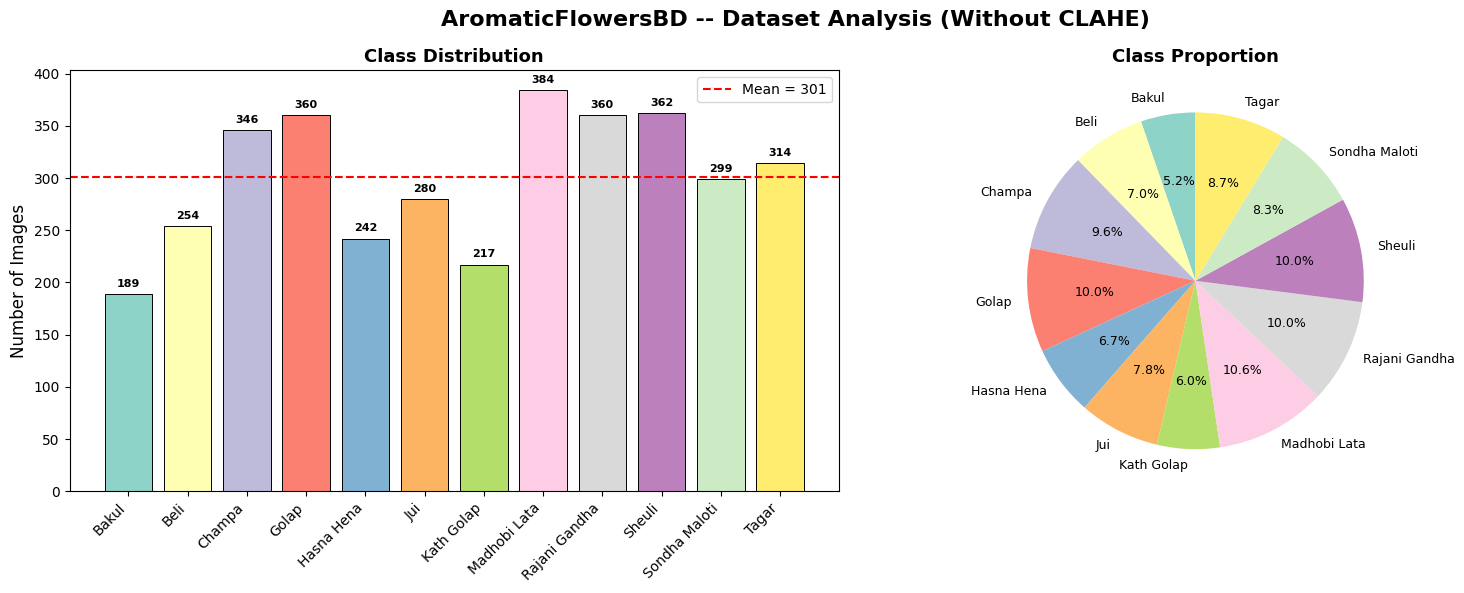

Min: 189 (Bakul)  Max: 384 (Madhobi Lata)
Imbalance Ratio: 2.03x


In [ ]:
# ---- Class Distribution Analysis ----
class_counts = df_all['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'AromaticFlowersBD -- Dataset Analysis ({'With CLAHE' if USE_CLAHE else 'Without CLAHE'})', fontsize=16, fontweight='bold')

colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = axes[0].bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].axhline(y=class_counts.mean(), color='red', linestyle='--', label=f'Mean = {class_counts.mean():.0f}')
axes[0].legend(fontsize=10)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Min: {class_counts.min()} ({class_counts.idxmin()})  Max: {class_counts.max()} ({class_counts.idxmax()})')
print(f'Imbalance Ratio: {class_counts.max()/class_counts.min():.2f}x')


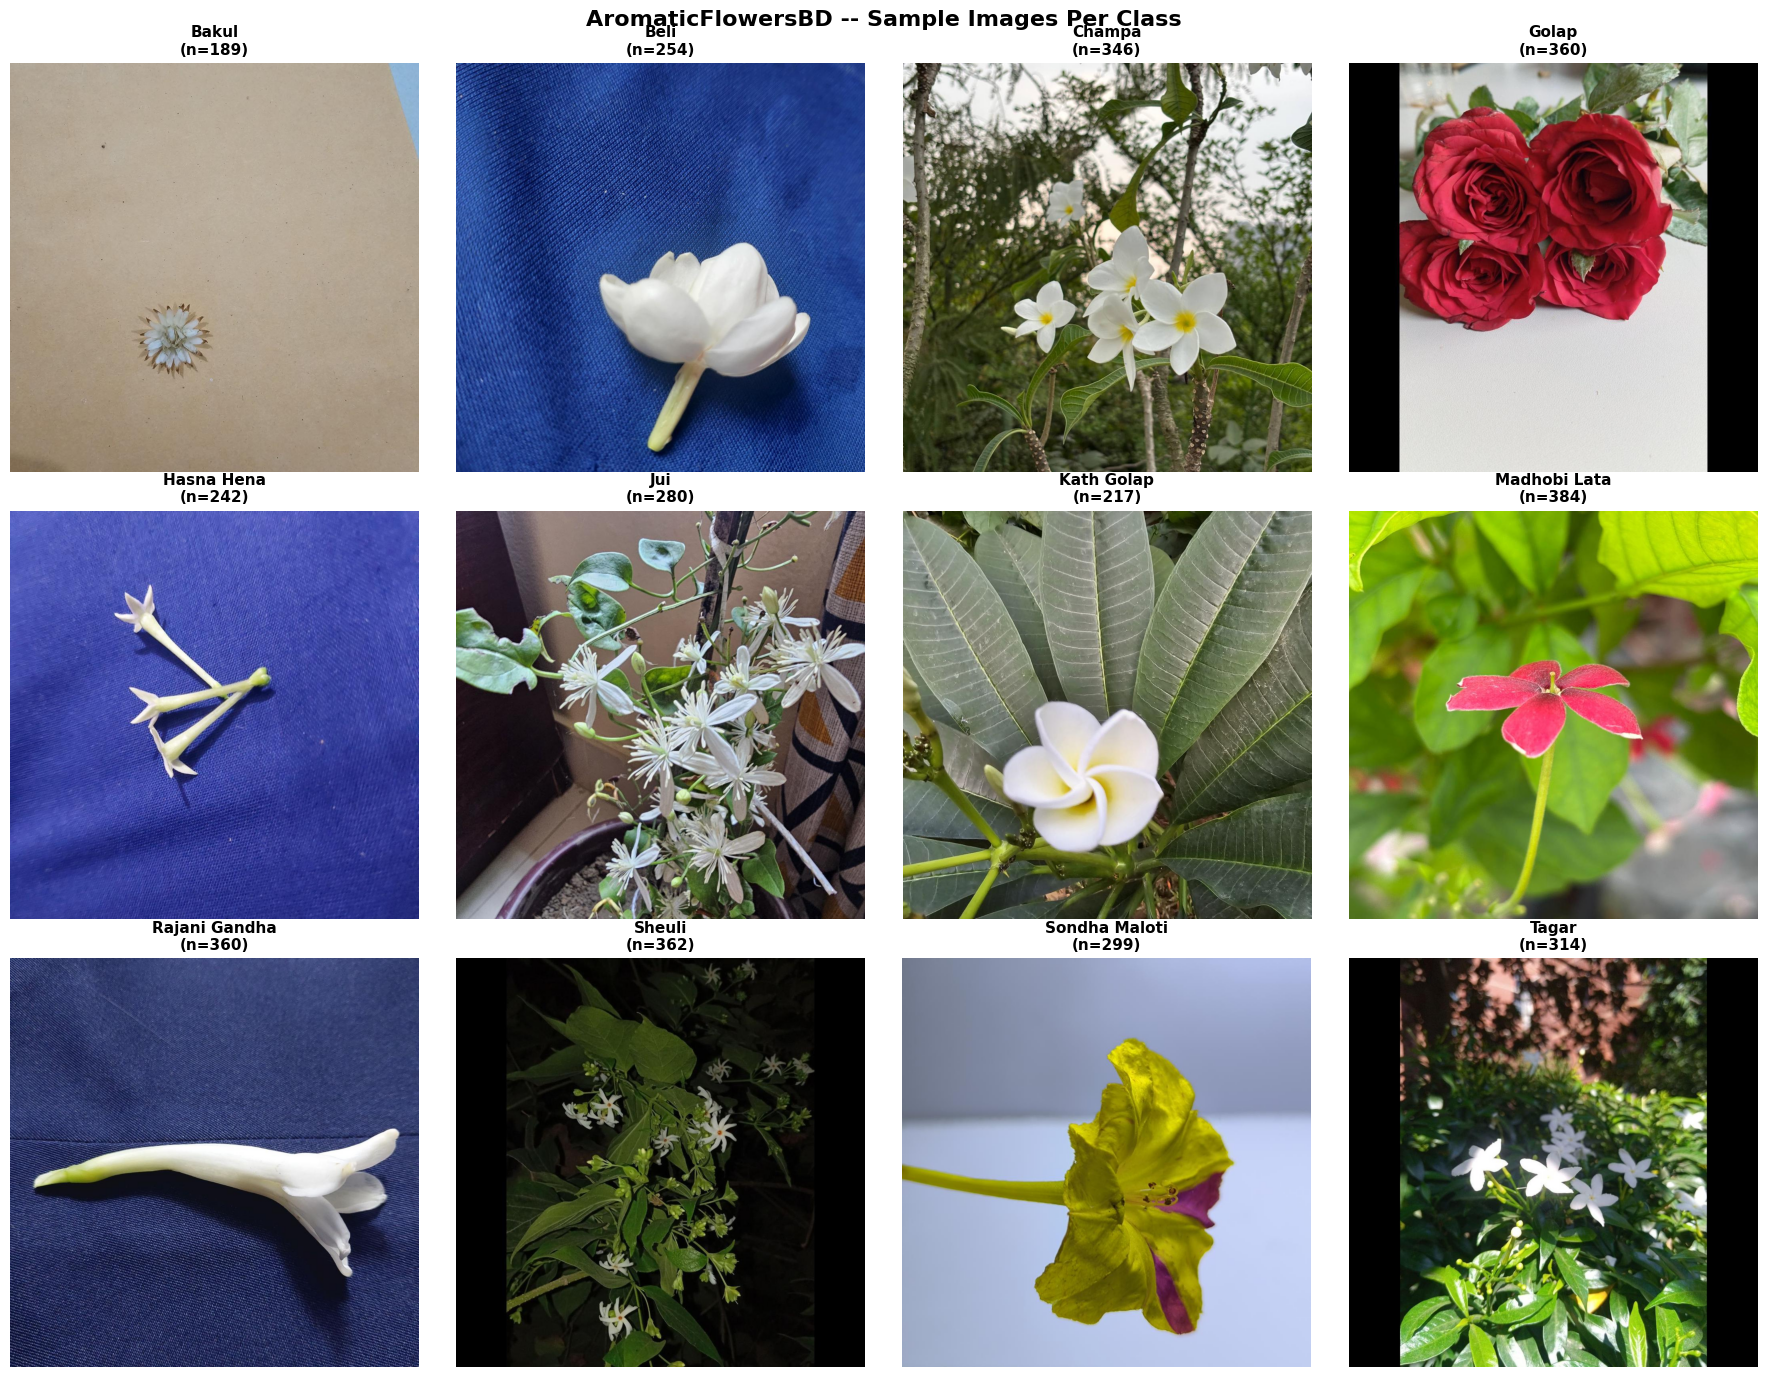

In [ ]:
# ---- Sample Images Per Class ----
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle('AromaticFlowersBD -- Sample Images Per Class', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, cls in enumerate(sorted(df_all['label'].unique())):
    cls_samples = df_all[df_all['label'] == cls].sample(1, random_state=SEED)
    img_path = cls_samples.iloc[0]['path']
    try:
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)
        axes[idx].set_title(f'{cls}\n(n={len(df_all[df_all["label"]==cls])})',
                            fontsize=11, fontweight='bold')
        axes[idx].axis('off')
    except Exception:
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'sample_images_per_class.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 3: Data Cleaning (Corrupted & Duplicate Removal)

In [ ]:
# ---- Step 1: Remove Corrupted Images ----
print('Checking for corrupted images...')
corrupted = []
for _, row in tqdm(df_all.iterrows(), total=len(df_all)):
    try:
        with Image.open(row['path']) as img:
            img.verify()
    except Exception:
        corrupted.append(row['path'])

print(f'Corrupted images found: {len(corrupted)}')
df_clean = df_all[~df_all['path'].isin(corrupted)].reset_index(drop=True)
print(f'Images after corruption removal: {len(df_clean)}')


Checking for corrupted images...


  0%|          | 0/3607 [00:00<?, ?it/s]

Corrupted images found: 0
Images after corruption removal: 3607


In [ ]:
# ---- Step 2: Duplicate Removal using Perceptual Hash ----
print('Checking for duplicate images using perceptual hashing...')
hash_dict = defaultdict(list)
for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    try:
        with Image.open(row['path']) as img:
            h = str(imagehash.phash(img))
            hash_dict[h].append(row['path'])
    except Exception:
        pass

duplicates = []
for h, paths in hash_dict.items():
    if len(paths) > 1:
        duplicates.extend(paths[1:])

print(f'Duplicate images found: {len(duplicates)}')
df_clean = df_clean[~df_clean['path'].isin(duplicates)].reset_index(drop=True)

print(f'\nData Cleaning Summary:')
print(f'  Original images:    {len(df_all)}')
print(f'  Corrupted removed:  {len(corrupted)}')
print(f'  Duplicates removed: {len(duplicates)}')
print(f'  Clean images:       {len(df_clean)}')


Checking for duplicate images using perceptual hashing...


  0%|          | 0/3607 [00:00<?, ?it/s]

Duplicate images found: 7

Data Cleaning Summary:
  Original images:    3607
  Corrupted removed:  0
  Duplicates removed: 7
  Clean images:       3600


## Phase 4: Train / Validation / Test Split (Stratified 60/20/20)

The dataset has a large enough number of images per class that a **60% train / 20% validation / 20% test** split still leaves sufficient data in each split for reliable validation and testing, while giving the model more training examples than a 70/15/15 split.

Train:      2160 images (60.0%)
Validation: 720 images (20.0%)
Test:       720 images (20.0%)

Class weights (inverse-frequency, computed from TRAIN split):
  Bakul          : n_train=113   weight=1.5183
  Beli           : n_train=152   weight=1.1287
  Champa         : n_train=206   weight=0.8328
  Golap          : n_train=216   weight=0.7943
  Hasna Hena     : n_train=145   weight=1.1832
  Jui            : n_train=168   weight=1.0212
  Kath Golap     : n_train=130   weight=1.3197
  Madhobi Lata   : n_train=230   weight=0.7459
  Rajani Gandha  : n_train=216   weight=0.7943
  Sheuli         : n_train=217   weight=0.7906
  Sondha Maloti  : n_train=179   weight=0.9585
  Tagar          : n_train=188   weight=0.9126


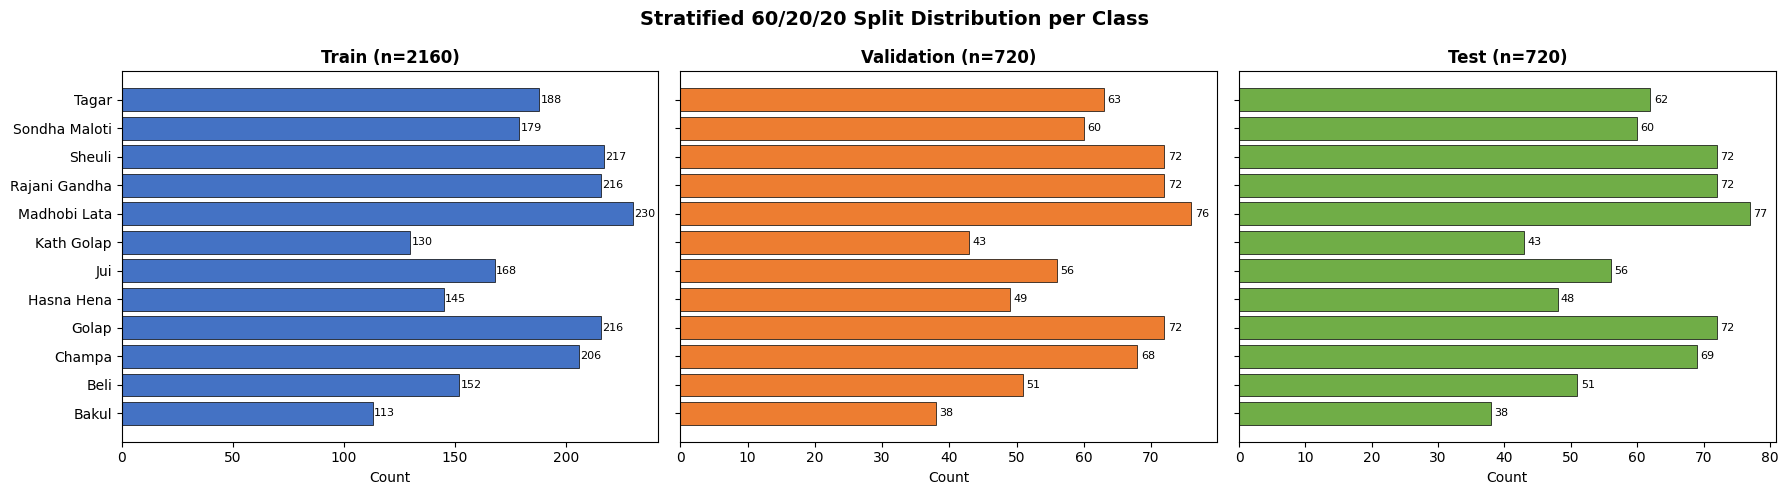

In [ ]:
# Create label encoding
unique_labels = sorted(df_clean['label'].unique())
label2idx = {l: i for i, l in enumerate(unique_labels)}
idx2label = {i: l for l, i in label2idx.items()}
df_clean['label_idx'] = df_clean['label'].map(label2idx)

# Stratified 60/20/20 split
X = df_clean['path'].values
y = df_clean['label_idx'].values

# First: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
# Then: split temp 50/50 -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train:      {len(X_train)} images ({len(X_train)/len(df_clean)*100:.1f}%)')
print(f'Validation: {len(X_val)} images ({len(X_val)/len(df_clean)*100:.1f}%)')
print(f'Test:       {len(X_test)} images ({len(X_test)/len(df_clean)*100:.1f}%)')

# ── Class weights for imbalanced CrossEntropyLoss ──
# Inverse-frequency weights computed from the TRAIN split only (never from
# val/test, to avoid leaking split information), rescaled to average to 1.0.
train_class_counts = np.bincount(y_train, minlength=len(unique_labels))
class_weights_np = 1.0 / train_class_counts
class_weights_np = class_weights_np / class_weights_np.sum() * len(unique_labels)
class_weights = torch.FloatTensor(class_weights_np).to(DEVICE)

print('\nClass weights (inverse-frequency, computed from TRAIN split):')
for name, cnt, w in zip(unique_labels, train_class_counts, class_weights_np):
    print(f'  {name:<15}: n_train={cnt:<4d}  weight={w:.4f}')

# Visualize split distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
colors_split = ['#4472C4', '#ED7D31', '#70AD47']

for ax, (split_name, labels), color in zip(axes, splits, colors_split):
    counts = Counter(labels)
    names = [idx2label[i] for i in sorted(counts.keys())]
    values = [counts[i] for i in sorted(counts.keys())]
    ax.barh(names, values, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{split_name} (n={len(labels)})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Count')
    for i, v in enumerate(values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=8)

plt.suptitle('Stratified 60/20/20 Split Distribution per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 5: Preprocessing (No CLAHE)

This is the **no-CLAHE** companion notebook: `USE_CLAHE = False`. No CLAHE (or any other contrast-enhancement step) is applied to train, validation, or test images anywhere in this notebook — only resizing and ImageNet normalization. See the companion `aromaticflowersbd_with_clahe.ipynb` notebook for the CLAHE-enabled pipeline.

In [ ]:
# No CLAHE is defined or used in this notebook by design.
# A no-op placeholder keeps downstream code (which conditionally inserts a
# CLAHE step based on USE_CLAHE) uniform between the two companion notebooks.
class CLAHETransform:
    """Not used when USE_CLAHE is False -- present only so shared code paths
    that reference CLAHETransform stay symmetrical with the CLAHE notebook."""
    def __call__(self, img):
        raise RuntimeError('CLAHETransform should never be invoked when USE_CLAHE=False')

print('USE_CLAHE = False -> no CLAHE step will be inserted into any transform pipeline.')


USE_CLAHE = False -> no CLAHE step will be inserted into any transform pipeline.


## Phase 5b: Dataset-Aligned Augmentation

The augmentation pipeline is restricted to exactly the 8 techniques below,
applied only to the **training** split on top of the resized image:

| # | Technique | Detail |
|---|-----------|--------|
| 1 | Horizontal Flip | mirror left-right |
| 2 | Vertical Flip | mirror top-bottom |
| 3 | Rotation 90° | rotate clockwise 90° |
| 4 | Rotation -90° | rotate counter-clockwise 90° |
| 5 | Brightness 30% Decreased | multiply pixel values by 0.70 |
| 6 | Brightness 30% Increased | multiply pixel values by 1.30 |
| 7 | 3 Pixel Blur | Gaussian blur, radius = 3 px |
| 8 | 2.5% Pixel Noise | Gaussian noise, std = 2.5% of the 0-255 range |

No other augmentation (no random-resized-crop, no color jitter, no
perspective/affine warps) is used.

**This notebook builds exactly ONE training transform and ONE eval transform**,
both driven by `USE_CLAHE` (False):
- Training transform: Resize -> augmentation -> (no CLAHE) -> Normalize
- Validation/Test transform: Resize -> (no CLAHE) -> Normalize (no augmentation)

Because train, validation, and test all read from the *same* `USE_CLAHE` flag,
CLAHE (or its absence) is applied consistently across every split — there is
no path in this notebook where one split gets CLAHE and another doesn't.

In [ ]:
# ── Augmentation transforms: ONLY the 8 techniques below ─────────
class BrightnessAdjust:
    """Multiplies pixel brightness by a fixed factor (0.70 = -30%, 1.30 = +30%)."""
    def __init__(self, factor: float):
        self.factor = factor
    def __call__(self, img):
        return ImageEnhance.Brightness(img).enhance(self.factor)


class PixelBlur:
    """Gaussian blur with a fixed pixel radius (default 3 px)."""
    def __init__(self, radius: int = 3):
        self.radius = radius
    def __call__(self, img):
        return img.filter(ImageFilter.GaussianBlur(radius=self.radius))


class PixelNoise:
    """Adds Gaussian noise whose std is a percentage of the 0-255 pixel range."""
    def __init__(self, pct: float = 2.5):
        self.pct = pct
    def __call__(self, img):
        arr = np.array(img).astype(np.float32)
        std = 255.0 * (self.pct / 100.0)
        noisy = arr + np.random.normal(0, std, arr.shape)
        return Image.fromarray(np.clip(noisy, 0, 255).astype(np.uint8))


class Rotate90:
    """Rotates by a fixed +90 or -90 degrees (no interpolation artifacts)."""
    def __init__(self, degrees: int):
        assert degrees in (90, -90)
        self.degrees = degrees
    def __call__(self, img):
        return img.rotate(self.degrees, expand=True).resize(img.size)


AUG_P_FLIP       = 0.5   # Horizontal / Vertical flip
AUG_P_ROTATE     = 0.3   # Rotation +90 / -90 (one or the other)
AUG_P_BRIGHTNESS = 0.3   # Brightness -30% / +30% (one or the other)
AUG_P_BLUR       = 0.15  # 3px blur
AUG_P_NOISE      = 0.15  # 2.5% pixel noise

def build_augmentation_ops():
    """Returns the list of the 8 allowed augmentation ops, applied independently."""
    return [
        transforms.RandomHorizontalFlip(p=AUG_P_FLIP),
        transforms.RandomVerticalFlip(p=AUG_P_FLIP),
        transforms.RandomApply([
            transforms.RandomChoice([Rotate90(90), Rotate90(-90)])
        ], p=AUG_P_ROTATE),
        transforms.RandomApply([
            transforms.RandomChoice([BrightnessAdjust(0.70), BrightnessAdjust(1.30)])
        ], p=AUG_P_BRIGHTNESS),
        transforms.RandomApply([PixelBlur(radius=3)], p=AUG_P_BLUR),
        transforms.RandomApply([PixelNoise(pct=2.5)], p=AUG_P_NOISE),
    ]


def build_train_transform(with_clahe: bool, with_augmentation: bool = True):
    """Single source of truth for the TRAIN transform. Augmentation (if any)
    runs first, CLAHE (if enabled) runs last, on top of the augmented image."""
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if with_augmentation:
        ops += build_augmentation_ops()
    if with_clahe:
        ops.append(CLAHETransform())
    ops += [transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)]
    return transforms.Compose(ops)


def build_eval_transform(with_clahe: bool):
    """Single source of truth for the VALIDATION/TEST transform (no augmentation)."""
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if with_clahe:
        ops.append(CLAHETransform())
    ops += [transforms.ToTensor(), transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)]
    return transforms.Compose(ops)


# The ONE training transform and ONE eval transform used throughout this notebook.
# Every loader below (train, val, test, scheduler-comparison, main training,
# ablation) is built from these two objects, so preprocessing can never drift
# between splits or experiments.
train_transform = build_train_transform(with_clahe=USE_CLAHE, with_augmentation=True)
eval_transform  = build_eval_transform(with_clahe=USE_CLAHE)

print(f'USE_CLAHE={USE_CLAHE} -> train_transform and eval_transform built consistently.')
print(train_transform)


USE_CLAHE=False -> train_transform and eval_transform built consistently.
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomApply(
    p=0.3
    RandomChoice(
)(p=None)
)
    RandomApply(
    p=0.3
    RandomChoice(
)(p=None)
)
    RandomApply(
    p=0.15
)
    RandomApply(
    p=0.15
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


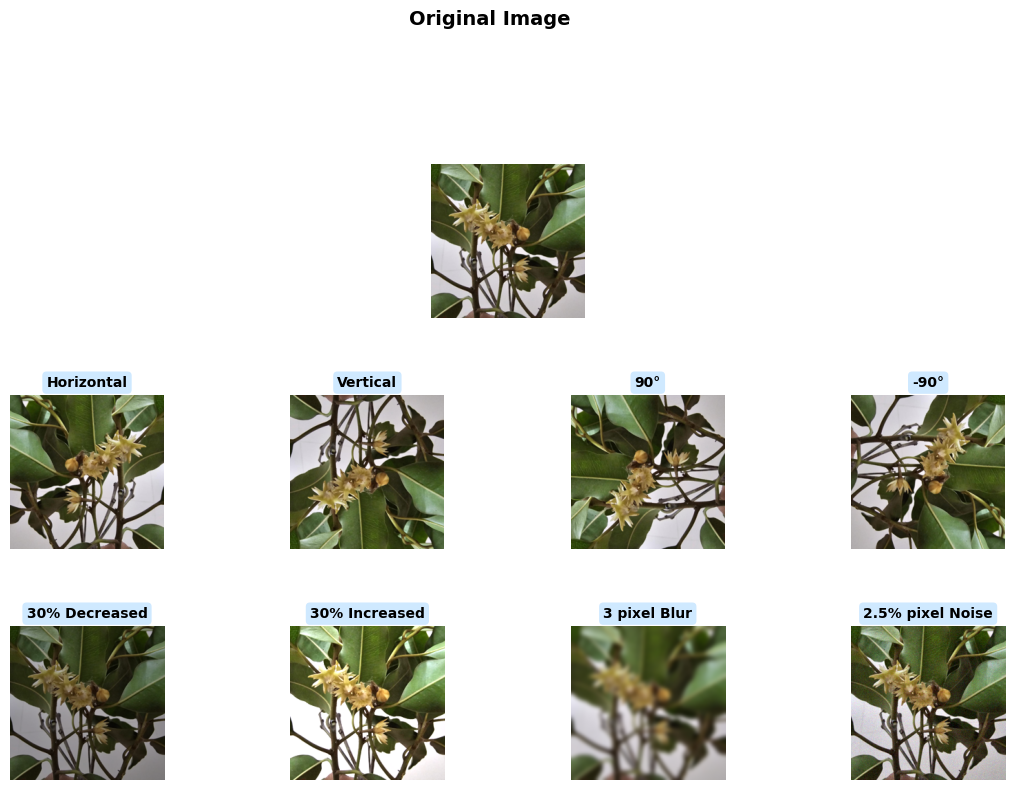

In [ ]:
# ---- Visualize the 8 Allowed Augmentation Techniques ----
demo_path = df_clean.iloc[0]['path']
demo_img = Image.open(demo_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

flip_h   = transforms.functional.hflip(demo_img)
flip_v   = transforms.functional.vflip(demo_img)
rot_90   = Rotate90(90)(demo_img)
rot_n90  = Rotate90(-90)(demo_img)
bright_d = BrightnessAdjust(0.70)(demo_img)
bright_i = BrightnessAdjust(1.30)(demo_img)
blur_3   = PixelBlur(radius=3)(demo_img)
noise_25 = PixelNoise(pct=2.5)(demo_img)

fig = plt.figure(figsize=(14, 14))
fig.suptitle('Original Image', fontsize=14, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(5, 4, figure=fig, hspace=0.5, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 1:3])
ax0.imshow(demo_img); ax0.axis('off')

def show(ax, img, label):
    ax.imshow(img); ax.axis('off')
    ax.set_title(label, fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='#cfe9ff', edgecolor='none'))

show(fig.add_subplot(gs[1, 0]), flip_h, 'Horizontal')
show(fig.add_subplot(gs[1, 1]), flip_v, 'Vertical')
show(fig.add_subplot(gs[1, 2]), rot_90, '90°')
show(fig.add_subplot(gs[1, 3]), rot_n90, '-90°')

show(fig.add_subplot(gs[2, 0]), bright_d, '30% Decreased')
show(fig.add_subplot(gs[2, 1]), bright_i, '30% Increased')
show(fig.add_subplot(gs[2, 2]), blur_3, '3 pixel Blur')
show(fig.add_subplot(gs[2, 3]), noise_25, '2.5% pixel Noise')

plt.savefig(OUT_DIR / 'figures' / 'augmentation_demo.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 6: Dataset & DataLoader Classes

One train/val/test loader triplet, built from the single `train_transform` / `eval_transform` pair defined above — the same preprocessing choice is applied to every split.

In [ ]:
class FlowerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


train_loader = DataLoader(
    FlowerDataset(X_train, y_train, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(
    FlowerDataset(X_val, y_val, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(
    FlowerDataset(X_test, y_test, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print(f'Preprocessing: USE_CLAHE={USE_CLAHE} applied identically to train/val/test.')


Train batches: 68 | Val: 23 | Test: 23
Preprocessing: USE_CLAHE=False applied identically to train/val/test.


## Phase 7: Model Definitions (ResNet50, DenseNet121, EfficientNet-B0, ConvNeXt-Tiny)

In [ ]:
def build_resnet50(num_classes: int, pretrained: bool = True) -> nn.Module:
    """ResNet-50 with custom classification head."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def build_densenet121(num_classes: int, pretrained: bool = True) -> nn.Module:
    """DenseNet-121 with custom classification head."""
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def build_efficientnet_b0(num_classes: int, pretrained: bool = True) -> nn.Module:
    """EfficientNet-B0 with custom classification head."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def build_convnext_tiny(num_classes: int, pretrained: bool = True) -> nn.Module:
    """ConvNeXt-Tiny with custom head."""
    model = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=0)
    in_features = model.num_features
    head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    model.head = head
    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model_configs = {
    'ResNet50':       build_resnet50(NUM_CLASSES),
    'DenseNet121':    build_densenet121(NUM_CLASSES),
    'EfficientNetB0': build_efficientnet_b0(NUM_CLASSES),
    'ConvNeXtTiny':   build_convnext_tiny(NUM_CLASSES),
}

print(f'{"Model":<20} {"Total Params":>15} {"Trainable Params":>18}')
print('-' * 56)
for name, m in model_configs.items():
    total, trainable = count_parameters(m)
    print(f'{name:<20} {total:>15,} {trainable:>18,}')
del model_configs


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 121MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

Model                   Total Params   Trainable Params
--------------------------------------------------------
ResNet50                  24,564,300         24,564,300
DenseNet121                7,485,836          7,485,836
EfficientNetB0             4,670,600          4,670,600
ConvNeXtTiny              28,219,500         28,219,500


## Phase 8: Training Infrastructure

- `train_model()` accepts `scheduler_name` — supports all 4 schedulers via `build_scheduler()`
- `save_to_drive()` called automatically on every validation-loss improvement
- `EarlyStopping` tracks `best_epoch`, `best_val_acc`, `best_val_loss`
- `train_one_epoch()` handles OneCycleLR batch-level stepping correctly

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, save_path=None):
        self.patience = patience; self.min_delta = min_delta
        self.save_path = save_path; self.counter = 0
        self.best_score = self.best_state = None
        self.best_val_loss = self.best_val_acc = self.best_epoch = None
        self.early_stop = False

    def __call__(self, val_loss, val_acc, epoch, model):
        score = -val_loss
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score; self.counter = 0
            self.best_val_loss = val_loss; self.best_val_acc = val_acc
            self.best_epoch = epoch; self._save(model)
        else:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True

    def _save(self, model):
        self.best_state = copy.deepcopy(model.state_dict())
        if self.save_path: torch.save(self.best_state, self.save_path)


def build_scheduler(name: str, optimizer, epochs: int, steps_per_epoch: int = 1):
    """
    Scheduler factory.
    CosineAnnealingLR : Smoothly decays LR to eta_min over T_max epochs. Best default.
    StepLR            : Drops by gamma every step_size=epochs//3 epochs. Simple baseline.
    ReduceLROnPlateau : Halves LR when val_loss stalls for 3 epochs. Adaptive.
    OneCycleLR        : Warm-up to max_lr=LR*10, then cosine decay. Super-convergence.
    """
    n = name.lower()
    if n == 'cosineannealinglr':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif n == 'steplr':
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif n == 'reducelronplateau':
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7)
    elif n == 'onecyclelr':
        return optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=LR * 10,
            total_steps=epochs * steps_per_epoch, pct_start=0.3, anneal_strategy='cos')
    else:
        raise ValueError(f'Unknown scheduler: {name}')


def train_one_epoch(model, loader, criterion, optimizer, scaler, scheduler, device,
                    is_onecycle=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(imgs); loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        if is_onecycle: scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item(); total += imgs.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='Eval', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs); loss = criterion(outputs, labels)
        probs = F.softmax(outputs, dim=1); _, predicted = outputs.max(1)
        total_loss += loss.item() * imgs.size(0)
        correct += predicted.eq(labels).sum().item(); total += imgs.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, 100.0 * correct / total,
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, model_name: str, train_loader, val_loader, device,
                epochs=NUM_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, scheduler_name='CosineAnnealingLR',
                class_weights=None):
    """
    Full training loop.
    scheduler_name : 'CosineAnnealingLR' | 'StepLR' | 'ReduceLROnPlateau' | 'OneCycleLR'
    class_weights  : optional torch.FloatTensor of per-class weights (inverse
                      class frequency, computed from the TRAIN split). Pass
                      None to train with a plain (unweighted) loss.
    Preprocessing (CLAHE or not) is entirely determined by which train_loader /
    val_loader is passed in -- this function does not toggle it, so the same
    consistent transform is used no matter which experiment calls it.
    """
    model = model.to(device)
    clahe_tag  = 'CLAHE' if USE_CLAHE else 'noCLAHE'
    run_tag    = f'{scheduler_name}_{clahe_tag}'
    local_path = OUT_DIR / 'models' / f'{model_name}_{run_tag}_best.pth'

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    is_onecycle = scheduler_name.lower() == 'onecyclelr'
    is_plateau  = scheduler_name.lower() == 'reducelronplateau'
    scheduler   = build_scheduler(scheduler_name, optimizer, epochs, len(train_loader))
    scaler      = torch.amp.GradScaler('cuda')
    es          = EarlyStopping(patience=patience, save_path=str(local_path))

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    prev_best_score = None
    start_time = time.time()

    print(f'\n{"="*65}')
    print(f'  Model: {model_name} | Scheduler: {scheduler_name} | CLAHE: {USE_CLAHE} | '
          f'Class-weighted loss: {class_weights is not None}')
    print(f'{"="*65}')

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, scheduler, device, is_onecycle)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

        if not is_onecycle:
            scheduler.step(val_loss) if is_plateau else scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f'Ep [{epoch:02d}/{epochs}] '
              f'TLoss:{train_loss:.4f} TAcc:{train_acc:.3f}% '
              f'VLoss:{val_loss:.4f} VAcc:{val_acc:.3f}% LR:{current_lr:.2e}')

        es(val_loss, val_acc, epoch, model)
        if es.best_score != prev_best_score:
            save_to_drive(model, model_name, run_tag, epoch, val_acc, val_loss)
            prev_best_score = es.best_score

        if es.early_stop:
            print(f'Early stopping at ep {epoch} (best@ep{es.best_epoch}, val_loss={es.best_val_loss:.4f})')
            break

    print(f'Training time: {(time.time()-start_time)/60:.1f} min')
    model.load_state_dict(es.best_state)
    return model, history


print('Training infrastructure ready.')


Training infrastructure ready.


## Phase 8b: Scheduler Comparison Experiment

Train **EfficientNetB0** with all 4 schedulers, using this notebook's single
`train_transform` / `eval_transform` pair (`USE_CLAHE=False`). The best
scheduler is then automatically selected for the full 4-model training run.

| Scheduler | Key Trait | Ideal Use Case |
|-----------|-----------|----------------|
| CosineAnnealingLR | Smooth decay, no monitoring | Default for most CNNs |
| StepLR | Discrete drops at fixed intervals | When rough schedule is fine |
| ReduceLROnPlateau | Adapts to val loss stagnation | Noisy training curves |
| OneCycleLR | Warm-up -> super-convergence | Fast training, fewer epochs |


In [ ]:
SCHEDULER_NAMES = ['CosineAnnealingLR', 'StepLR', 'ReduceLROnPlateau', 'OneCycleLR']
scheduler_results = {}  # {scheduler_name: history}
SCHED_EPOCHS = min(NUM_EPOCHS, 30)  # Limit epochs for comparison speed

print(f'Running scheduler comparison on EfficientNetB0 ({SCHED_EPOCHS} epochs each, USE_CLAHE={USE_CLAHE})...')
for sched_name in SCHEDULER_NAMES:
    torch.cuda.empty_cache()
    m = build_efficientnet_b0(NUM_CLASSES, pretrained=True)
    _, hist = train_model(
        m, 'EfficientNetB0', train_loader, val_loader, DEVICE,
        epochs=SCHED_EPOCHS, lr=LR, patience=PATIENCE,
        scheduler_name=sched_name,
        class_weights=class_weights)
    scheduler_results[sched_name] = hist
    del m; torch.cuda.empty_cache()

print('\nScheduler comparison complete!')


Running scheduler comparison on EfficientNetB0 (10 epochs each, USE_CLAHE=False)...

  Model: EfficientNetB0 | Scheduler: CosineAnnealingLR | CLAHE: False | Class-weighted loss: True


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [01/10] TLoss:1.9137 TAcc:46.713% VLoss:1.0115 VAcc:91.944% LR:9.76e-05
  -> Checkpoint saved to Drive & Local: EfficientNetB0_CosineAnnealingLR_noCLAHE_ep01_acc91.94.pth


Train:   0%|          | 0/68 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [09/10] TLoss:0.5902 TAcc:99.352% VLoss:0.5576 VAcc:99.861% LR:4.81e-05
  -> Checkpoint saved to Drive & Local: EfficientNetB0_OneCycleLR_noCLAHE_ep09_acc99.86.pth


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [10/10] TLoss:0.5831 TAcc:99.537% VLoss:0.5594 VAcc:99.583% LR:1.49e-08
Training time: 7.4 min

Scheduler comparison complete!


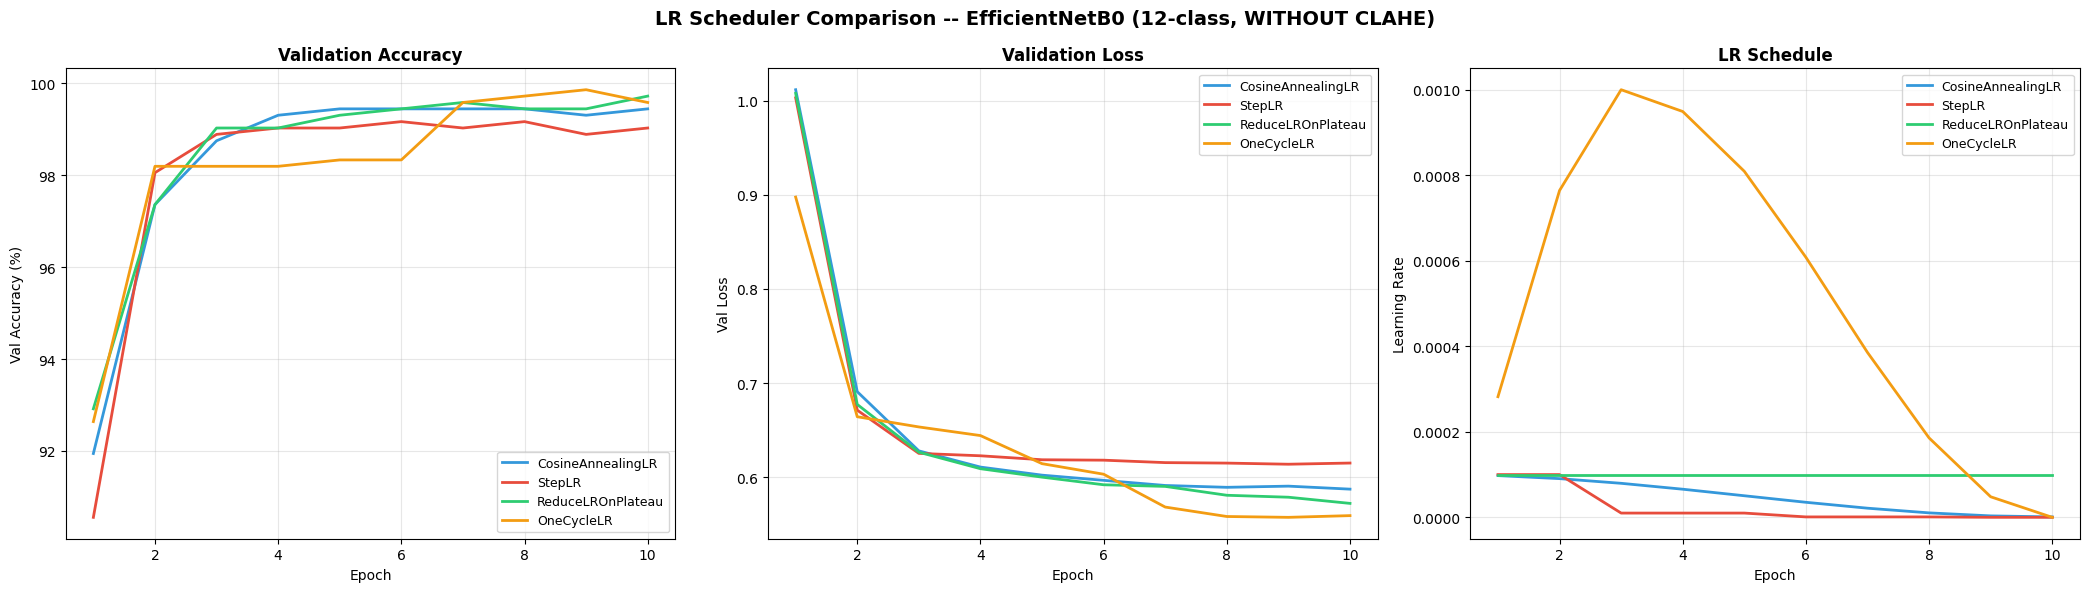

Best Val Acc per Scheduler:
  CosineAnnealingLR     : 99.444% (epoch 5)
  StepLR                : 99.167% (epoch 6)
  ReduceLROnPlateau     : 99.722% (epoch 10)
  OneCycleLR            : 99.861% (epoch 9)

BEST_SCHEDULER = "OneCycleLR" (99.861%)
This will be used for the full 4-model training run.


In [ ]:
# ── Plot scheduler comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'LR Scheduler Comparison -- EfficientNetB0 (12-class, WITHOUT CLAHE)',
             fontsize=14, fontweight='bold')
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

for ax, (key, ylabel, title) in zip(axes, [
    ('val_acc',  'Val Accuracy (%)', 'Validation Accuracy'),
    ('val_loss', 'Val Loss',         'Validation Loss'),
    ('lr',       'Learning Rate',    'LR Schedule'),
]):
    for (sname, hist), clr in zip(scheduler_results.items(), colors):
        ax.plot(range(1, len(hist[key])+1), hist[key], label=sname, color=clr, lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'scheduler_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

sched_best_acc = {k: max(v['val_acc']) for k, v in scheduler_results.items()}
print('Best Val Acc per Scheduler:')
for k, v in sched_best_acc.items():
    ep = scheduler_results[k]['val_acc'].index(v) + 1
    print(f'  {k:<22}: {v:.3f}% (epoch {ep})')

BEST_SCHEDULER = max(sched_best_acc, key=sched_best_acc.get)
print(f'\nBEST_SCHEDULER = "{BEST_SCHEDULER}" ({sched_best_acc[BEST_SCHEDULER]:.3f}%)')
print('This will be used for the full 4-model training run.')


## Phase 9: Train All 4 Models

Uses `BEST_SCHEDULER` from Phase 8b. A single training run — all four models
share the same `train_loader` / `val_loader` built with `USE_CLAHE=False` — "
so preprocessing stays identical across models and across train/val/test.

In [ ]:
model_builders = {
    'ResNet50':       build_resnet50,
    'DenseNet121':    build_densenet121,
    'EfficientNetB0': build_efficientnet_b0,
    'ConvNeXtTiny':   build_convnext_tiny,
}

print(f'=== Training all 4 models (USE_CLAHE={USE_CLAHE}) ===')
trained_models = {}; all_histories = {}
for model_name, builder in model_builders.items():
    torch.cuda.empty_cache()
    m = builder(NUM_CLASSES, pretrained=True)
    trained_m, hist = train_model(
        m, model_name, train_loader, val_loader, DEVICE,
        epochs=NUM_EPOCHS, scheduler_name=BEST_SCHEDULER,
        class_weights=class_weights)
    trained_models[model_name] = trained_m; all_histories[model_name] = hist
print('\nAll models trained.')


=== Training all 4 models (USE_CLAHE=False) ===

  Model: ResNet50 | Scheduler: OneCycleLR | CLAHE: False | Class-weighted loss: True


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [01/10] TLoss:1.8124 TAcc:51.435% VLoss:0.7149 VAcc:96.528% LR:2.82e-04
  -> Checkpoint saved to Drive & Local: ResNet50_OneCycleLR_noCLAHE_ep01_acc96.53.pth


Train:   0%|          | 0/68 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [09/10] TLoss:0.6167 TAcc:98.981% VLoss:0.6102 VAcc:98.472% LR:4.81e-05
  -> Checkpoint saved to Drive & Local: ConvNeXtTiny_OneCycleLR_noCLAHE_ep09_acc98.47.pth


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Eval:   0%|          | 0/23 [00:00<?, ?it/s]

Ep [10/10] TLoss:0.6022 TAcc:99.352% VLoss:0.6070 VAcc:98.611% LR:1.49e-08
  -> Checkpoint saved to Drive & Local: ConvNeXtTiny_OneCycleLR_noCLAHE_ep10_acc98.61.pth
Training time: 8.2 min

All models trained.


## Phase 10: Training Curves Visualization

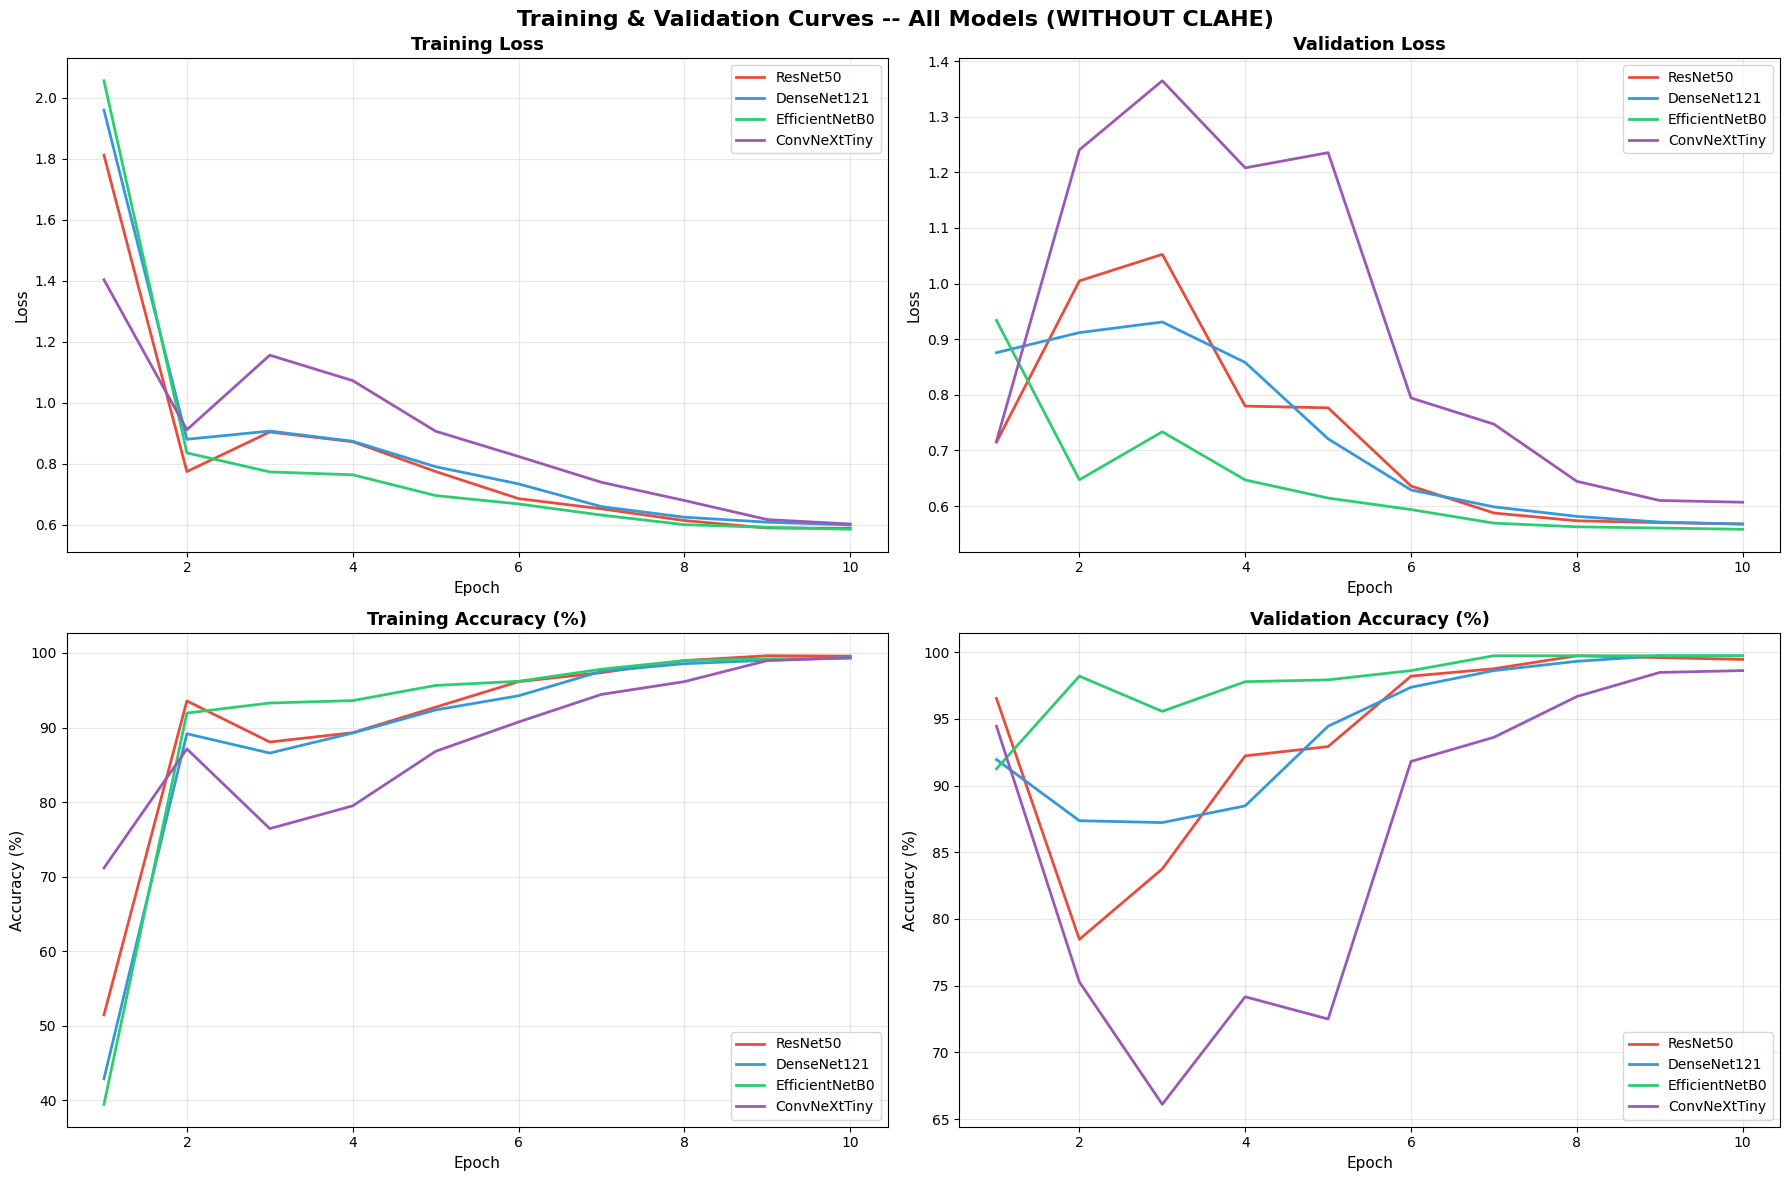

In [ ]:
def plot_training_curves(all_histories, save_path=None):
    colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Training & Validation Curves -- All Models (WITHOUT CLAHE)', fontsize=16, fontweight='bold')

    for (model_name, history), color in zip(all_histories.items(), colors):
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0, 0].plot(epochs, history['train_loss'], label=model_name, color=color, linewidth=2)
        axes[0, 1].plot(epochs, history['val_loss'], label=model_name, color=color, linewidth=2)
        axes[1, 0].plot(epochs, history['train_acc'], label=model_name, color=color, linewidth=2)
        axes[1, 1].plot(epochs, history['val_acc'], label=model_name, color=color, linewidth=2)

    titles = ['Training Loss', 'Validation Loss', 'Training Accuracy (%)', 'Validation Accuracy (%)']
    ylabels = ['Loss', 'Loss', 'Accuracy (%)', 'Accuracy (%)']

    for ax, title, ylabel in zip(axes.flatten(), titles, ylabels):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_training_curves(all_histories, save_path=OUT_DIR / 'figures' / 'training_curves.png')


## Phase 11: Individual Model Evaluation (Test Set)

In [ ]:
def compute_metrics(y_true, y_pred, y_probs, class_names):
    y_probs = np.array(y_probs, dtype=np.float64)
    y_probs = y_probs / y_probs.sum(axis=1, keepdims=True)

    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
        'kappa':     cohen_kappa_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro'),
    }

criterion = nn.CrossEntropyLoss()
test_results = {}

print('='*75)
print('TEST SET RESULTS')
print('='*75)

for model_name, model in trained_models.items():
    model.eval()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, DEVICE)
    metrics = compute_metrics(labels, preds, probs, CLASS_NAMES)
    test_results[model_name] = {
        'preds': preds, 'probs': probs, 'labels': labels, 'metrics': metrics
    }
    print(f'{model_name:20s} | Acc: {metrics["accuracy"]*100:.3f}% | '
          f'F1: {metrics["f1"]*100:.3f}% | '
          f'MCC: {metrics["mcc"]:.4f} | '
          f'AUC: {metrics["roc_auc"]:.4f} | '
          f'Kappa: {metrics["kappa"]:.4f}')

print('='*75)


TEST SET RESULTS


Eval:   0%|          | 0/23 [00:00<?, ?it/s]

ResNet50             | Acc: 99.028% | F1: 99.034% | MCC: 0.9894 | AUC: 0.9999 | Kappa: 0.9894


Eval:   0%|          | 0/23 [00:00<?, ?it/s]

DenseNet121          | Acc: 99.583% | F1: 99.479% | MCC: 0.9954 | AUC: 1.0000 | Kappa: 0.9954


Eval:   0%|          | 0/23 [00:00<?, ?it/s]

EfficientNetB0       | Acc: 99.583% | F1: 99.620% | MCC: 0.9954 | AUC: 1.0000 | Kappa: 0.9954


Eval:   0%|          | 0/23 [00:00<?, ?it/s]

ConvNeXtTiny         | Acc: 98.333% | F1: 98.368% | MCC: 0.9818 | AUC: 0.9999 | Kappa: 0.9817


In [ ]:
# ---- Metrics Comparison Table ----
rows = []
for model_name, result in test_results.items():
    m = result['metrics']
    rows.append({
        'Model': model_name,
        'Accuracy (%)': f"{m['accuracy']*100:.3f}",
        'Precision (%)': f"{m['precision']*100:.3f}",
        'Recall (%)': f"{m['recall']*100:.3f}",
        'F1 (%)': f"{m['f1']*100:.3f}",
        'MCC': f"{m['mcc']:.4f}",
        'Cohen Kappa': f"{m['kappa']:.4f}",
        'ROC-AUC': f"{m['roc_auc']:.4f}",
    })

metrics_df = pd.DataFrame(rows)
print('\n=== Individual Model Performance on Test Set ===')
print(metrics_df.to_string(index=False))
metrics_df.to_csv(OUT_DIR / 'individual_model_metrics.csv', index=False)



=== Individual Model Performance on Test Set ===
         Model Accuracy (%) Precision (%) Recall (%) F1 (%)    MCC Cohen Kappa ROC-AUC
      ResNet50       99.028        99.030     99.063 99.034 0.9894      0.9894  0.9999
   DenseNet121       99.583        99.515     99.448 99.479 0.9954      0.9954  1.0000
EfficientNetB0       99.583        99.621     99.630 99.620 0.9954      0.9954  1.0000
  ConvNeXtTiny       98.333        98.390     98.389 98.368 0.9818      0.9817  0.9999


## Phase 12: Confusion Matrices

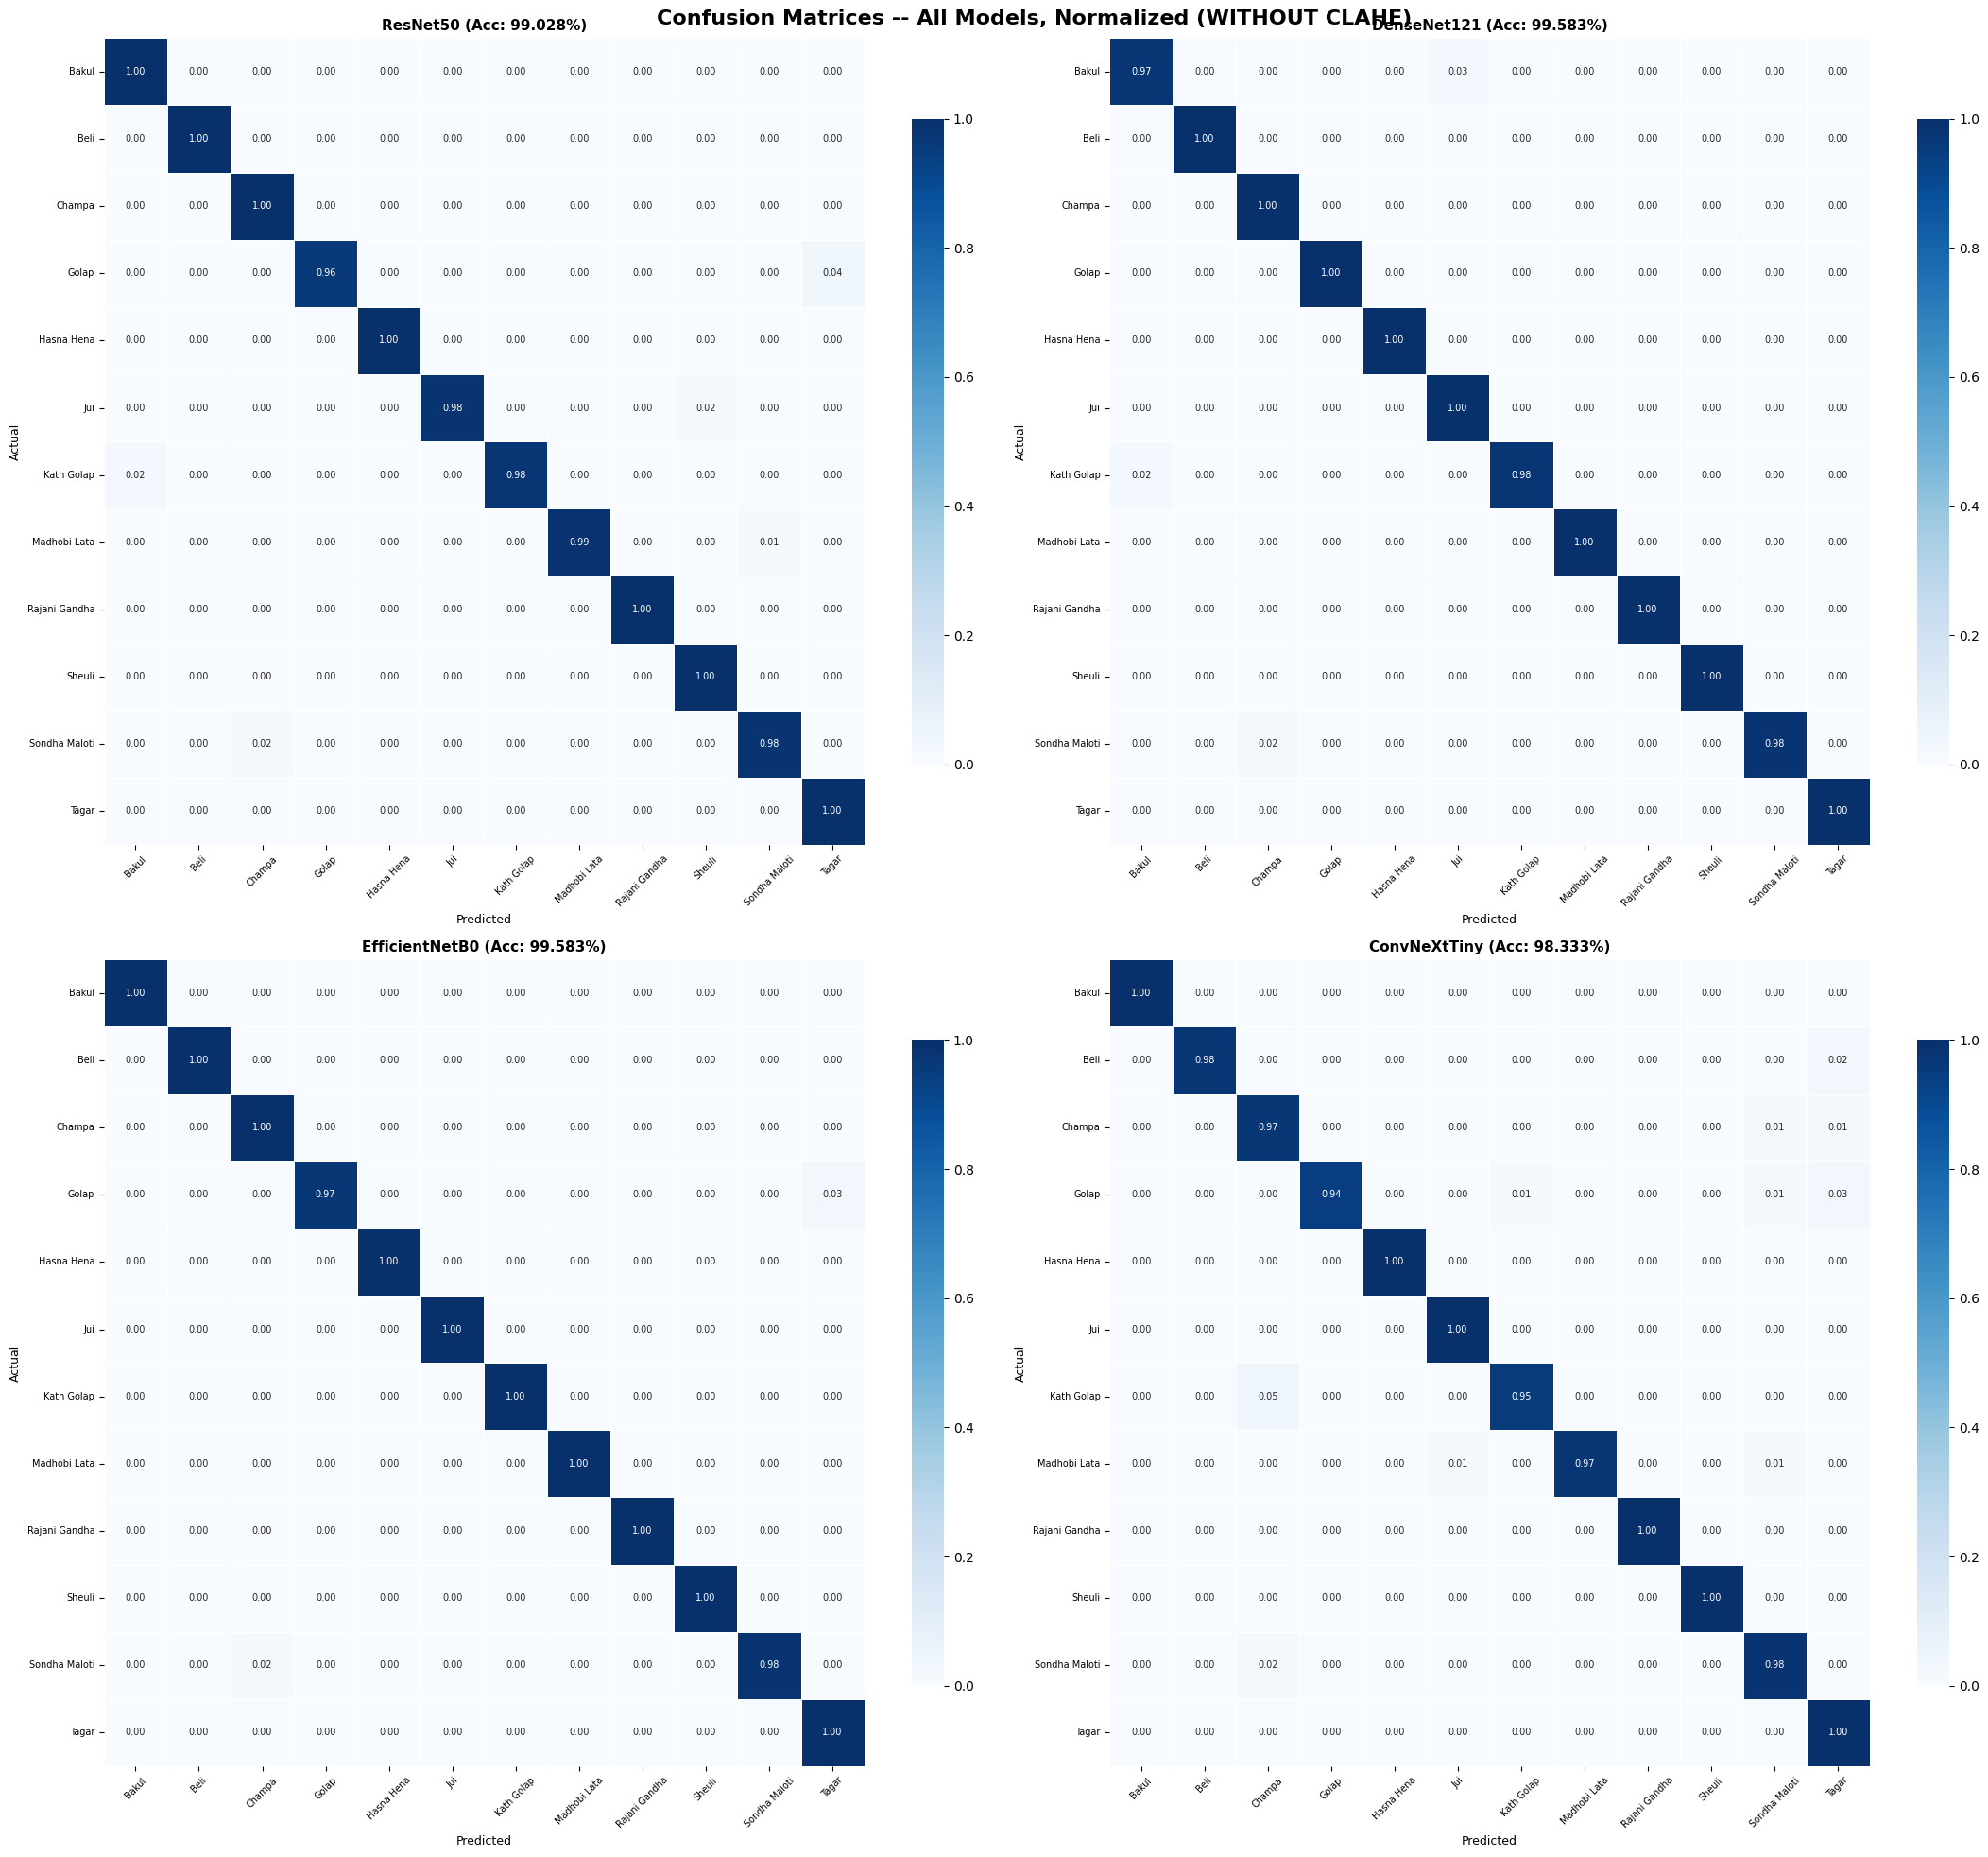

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 7})
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)


fig, axes = plt.subplots(2, 2, figsize=(22, 20))
fig.suptitle(f'Confusion Matrices -- All Models, Normalized (WITHOUT CLAHE)', fontsize=16, fontweight='bold')

for ax, (model_name, result) in zip(axes.flatten(), test_results.items()):
    plot_confusion_matrix(
        result['labels'], result['preds'], CLASS_NAMES,
        f'{model_name} (Acc: {result["metrics"]["accuracy"]*100:.3f}%)', ax
    )

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 13: ROC Curves (Multi-Class OvR)

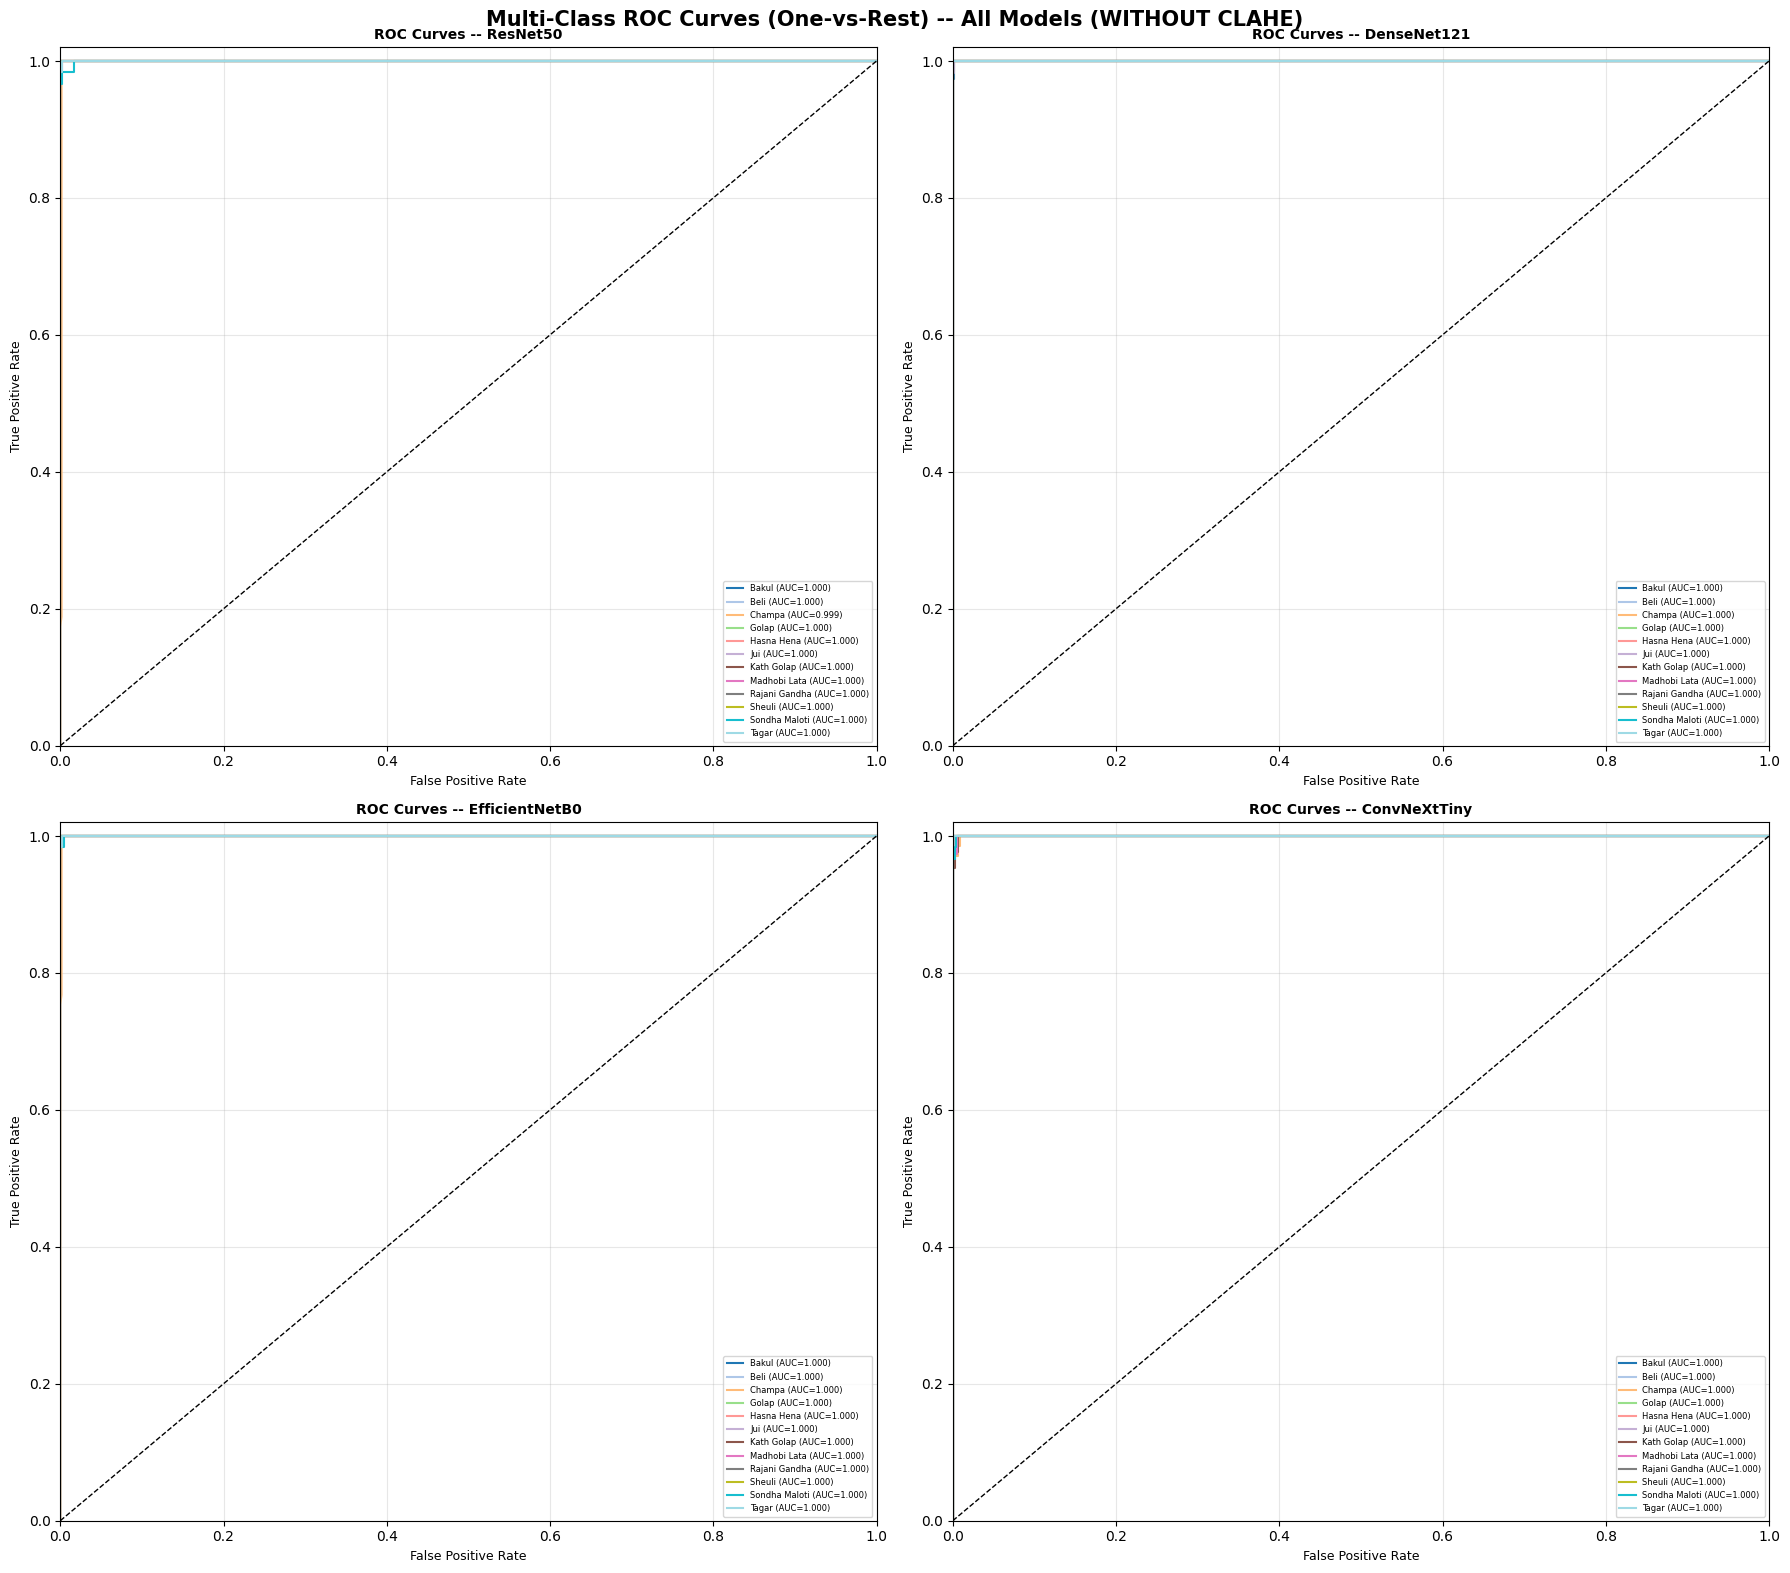

In [ ]:
def plot_roc_curves(y_true, y_probs, class_names, model_name, ax):
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))

    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'ROC Curves -- {model_name}', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=6, ncol=1)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle(f'Multi-Class ROC Curves (One-vs-Rest) -- All Models (WITHOUT CLAHE)', fontsize=15, fontweight='bold')

for ax, (model_name, result) in zip(axes.flatten(), test_results.items()):
    plot_roc_curves(result['labels'], result['probs'], CLASS_NAMES, model_name, ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


## Phase 14: Grad-CAM Explainability

Grad-CAM is generated for each individual model, and then — in the same format, style, and grid layout — for the **Weighted Ensemble** as a whole, by combining the per-model CAMs with the same validation-accuracy weights used for the ensemble's predictions.

In [ ]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping (Grad-CAM)."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        with torch.enable_grad():
            output = self.model(x)
            if class_idx is None:
                class_idx = output.argmax(dim=1).item()
            self.model.zero_grad()
            score = output[0, class_idx]
            score.backward()

        pooled_gradients = self.gradients.mean(dim=[0, 2, 3])
        cam = self.activations[0].clone()
        for i, grad in enumerate(pooled_gradients):
            cam[i] *= grad

        cam = cam.mean(dim=0)
        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam.cpu().numpy(), class_idx


def get_target_layer(model, model_name):
    """Get the best convolutional layer for sharp Grad-CAM."""
    if model_name == 'ResNet50':
        return model.layer4[-1].conv2
    elif model_name == 'DenseNet121':
        return model.features.denseblock4.denselayer16.conv2
    elif model_name == 'EfficientNetB0':
        return model.features[-1][0]
    elif model_name == 'ConvNeXtTiny':
        return list(model.stages[-1].blocks.children())[-1].conv_dw
    return None


def overlay_gradcam(img_tensor, cam, alpha=0.5):
    """Overlay CAM heatmap on original image."""
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    img_uint8 = np.uint8(255 * img)

    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap, alpha, 0)
    return img_uint8, heatmap, overlay


print('Grad-CAM class defined.')


: 

In [ ]:
# ---- Generate Grad-CAM for all 4 individual models, all 12 classes ----
test_df = pd.DataFrame({'path': X_test, 'label': y_test})

gradcam_samples = {}
for cls_idx in range(NUM_CLASSES):
    cls_samples = test_df[test_df['label'] == cls_idx]
    if len(cls_samples) > 0:
        gradcam_samples[cls_idx] = cls_samples.iloc[0]['path']

col_labels = ['Original Image', 'Grad-CAM Heatmap', 'Overlay']

for model_name, model in trained_models.items():
    model = model.to(DEVICE)
    target_layer = get_target_layer(model, model_name)

    if target_layer is None:
        print(f'Skipping {model_name} -- target layer not found.')
        continue

    try:
        gradcam = GradCAM(model, target_layer)

        fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(15, NUM_CLASSES * 4))
        fig.suptitle(
            f'Grad-CAM Explainability -- {model_name}\n(Original | Heatmap | Overlay)',
            fontsize=15, fontweight='bold', y=1.01
        )

        for col, lbl in enumerate(col_labels):
            axes[0, col].set_title(lbl, fontsize=12, fontweight='bold', pad=10)

        for cls_idx, img_path in gradcam_samples.items():
            img = Image.open(img_path).convert('RGB')
            img_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

            cam, pred_cls = gradcam.generate(img_tensor)
            original, heatmap, overlay = overlay_gradcam(img_tensor, cam)

            axes[cls_idx, 0].imshow(original)
            axes[cls_idx, 0].set_ylabel(
                f'{CLASS_NAMES[cls_idx]}\n(Pred: {CLASS_NAMES[pred_cls]})',
                fontsize=9, fontweight='bold'
            )
            axes[cls_idx, 0].axis('off')

            axes[cls_idx, 1].imshow(heatmap)
            axes[cls_idx, 1].axis('off')

            axes[cls_idx, 2].imshow(overlay)
            correct = (pred_cls == cls_idx)
            axes[cls_idx, 2].set_title(
                'Correct' if correct else 'Wrong',
                color='green' if correct else 'red', fontsize=9
            )
            axes[cls_idx, 2].axis('off')

        plt.tight_layout()
        save_path = OUT_DIR / 'gradcam' / f'gradcam_{model_name}.png'
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Grad-CAM saved: {save_path}')

    except Exception as e:
        print(f'Grad-CAM error ({model_name}): {e}')
        import traceback; traceback.print_exc()
